# Code Summarization via LSTM

**CSCI 455/555 — GenAI for SD, Assignment 2**

Walker Hyman

This notebook trains an encoder-decoder LSTM to generate natural language summaries for Java methods.

## Data
- **Source:** Public GitHub Java repositories mined by `get_data.py` via the GitHub Search API and shallow cloning.
- **Pre-processing:** Each Javadoc-backed Java method is flattened to one whitespace-normalized line. Each summary is the lowercased Javadoc summary section from the preceding Javadoc, stopping at the first blank line or Javadoc tag. Constructors plus noisy URL-heavy / non-English summaries are excluded.
- **Split:** ~50,000 training pairs, 1,000 validation pairs.
- **Tokenization & Embeddings:** CodeT5+ (Salesforce/codet5p-220m) via the provided `get_codet5_embeddings.py` script. Vocab size = 32,100, embedding dim = 768.

## Model
- 2-layer encoder-decoder LSTM with additive attention over source tokens.
- Pretrained CodeT5+ embeddings (fine-tuned during training).
- Early stopping on BLEU-1 computed over the full validation set (patience=3).

## Evaluation
- BLEU-1/2/3/4 (sacrebleu), METEOR (nltk), BERTScore, SIDE.


## 1. Setup & Dependencies

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

!pip install -q numpy"<2" datasets transformers==4.46.0 sentencepiece==0.1.99 sacrebleu nltk bert-score matplotlib tqdm

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [2]:
import warnings
warnings.filterwarnings('ignore', message='TypedStorage is deprecated', category=UserWarning)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import os, csv, random
import matplotlib.pyplot as plt

ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def artifact_path(name):
    return os.path.join(ARTIFACT_DIR, name)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


Device: cuda


## 2. Data Collection & Pre-processing

We mine Java method-summary pairs directly from public GitHub repositories. `get_data.py` searches for Java repositories, shallow-clones them, extracts methods with immediately preceding Javadocs, excludes constructors, and uses the Javadoc summary section as the target summary.

Pre-processing steps:
1. Search GitHub for public Java repositories and clone them into a local cache.
2. Extract methods with an immediately preceding Javadoc block while excluding constructors.
3. Use the Javadoc summary section as the summary, stopping at the first blank line or Javadoc tag, lowercase it, and normalize whitespace.
4. Flatten each Java method into a single whitespace-normalized line.
5. Filter out trivially short methods, trivial getters/setters, URL-heavy or non-English summaries, and other noisy pairs.
6. Build repo-disjoint train / validation splits.
7. Write `.txt` files (one sample per line) plus metadata for the embedding script.

The verification cell below checks the required split sizes, confirms the repo-disjoint split, and prints representative source repositories from `dataset_metadata.json` so the notebook explicitly documents dataset provenance.


In [3]:
# Mine GitHub repos and write train/val .txt files + dataset_metadata.json to artifacts/
# Set GITHUB_TOKEN to avoid API rate limits.
!python get_data.py --output-dir {ARTIFACT_DIR}

Loaded 700 cached repositories from .dataset_cache/repo_list.csv
Cloning 20 repositories with 8 workers...
  20/20 repos processed (cached: apache/dubbo)
Cloned or reused 20 repositories


Processed 10/20 repos | repos with usable pairs so far: 6


Processed 20/20 repos | repos with usable pairs so far: 14
Candidate-pair total after repos 1-20: 1724
Cloning 20 repositories with 8 workers...


  20/20 repos processed (cached: apache/kafka)
Cloned or reused 20 repositories


Processed 10/20 repos | repos with usable pairs so far: 8


...

Processed 20/20 repos | repos with usable pairs so far: 17
Candidate-pair total after repos 661-680: 52069
Cloning 20 repositories with 8 workers...


  20/20 repos processed (cached: Ashok-Varma/BottomNavigation)
Cloned or reused 20 repositories


Processed 10/20 repos | repos with usable pairs so far: 9


Processed 20/20 repos | repos with usable pairs so far: 17
Candidate-pair total after repos 681-700: 52508
Collected 52508 unique candidate pairs across 557 repositories


Wrote dataset files:
  artifacts/train_code.txt     50000
  artifacts/train_summary.txt  50000
  artifacts/val_code.txt       1000
  artifacts/val_summary.txt    1000
  artifacts/dataset_metadata.json


In [ ]:
# Verify counts and document source repositories
import json

counts = {}
for f in ['train_code.txt', 'train_summary.txt', 'val_code.txt', 'val_summary.txt']:
    path = artifact_path(f)
    with open(path) as fh:
        n = sum(1 for _ in fh)
    counts[f] = n
    print(f'{path}: {n} lines')

with open(artifact_path('dataset_metadata.json'), 'r', encoding='utf-8') as f:
    metadata = json.load(f)

train_repos = [repo for repo in metadata['repos'] if repo['split'] == 'train' and repo['pairs_after_global_dedupe'] > 0]
val_repos = [repo for repo in metadata['repos'] if repo['split'] == 'val' and repo['pairs_after_global_dedupe'] > 0]

train_repo_names = {repo['repo'] for repo in train_repos}
val_repo_names = {repo['repo'] for repo in val_repos}
assert train_repo_names.isdisjoint(val_repo_names), 'Train and validation repositories should be repo-disjoint.'

print(f'\nRepo-disjoint split: {len(train_repos)} train repos, {len(val_repos)} val repos')
print(f'Candidate repositories indexed: {len(metadata["repos"])}')
print(f'Usable repositories with extracted pairs: {len(train_repos) + len(val_repos)}')
print(f'Summary source: {metadata["filters"]["summary_source"]}')

print('\n--- Example train repositories ---')
for repo in train_repos[:10]:
    print(f"{repo['repo']} | pairs={repo['pairs_after_global_dedupe']} | {repo['html_url']}")

print('\n--- Example validation repositories ---')
for repo in val_repos[:10]:
    print(f"{repo['repo']} | pairs={repo['pairs_after_global_dedupe']} | {repo['html_url']}")

# Show a few samples
print('\n--- Sample code ---')
with open(artifact_path('train_code.txt')) as f:
    for i, line in enumerate(f):
        if i >= 2:
            break
        print(line.strip()[:200], '...')

print('\n--- Sample summaries ---')
with open(artifact_path('train_summary.txt')) as f:
    for i, line in enumerate(f):
        if i >= 2:
            break
        print(line.strip())


artifacts/train_code.txt: 50000 lines
artifacts/train_summary.txt: 50000 lines
artifacts/val_code.txt: 1000 lines
artifacts/val_summary.txt: 1000 lines

Repo-disjoint split: 546 train repos, 11 val repos
Candidate repositories indexed: 700
Usable repositories with extracted pairs: 557
Summary source: Javadoc summary section immediately preceding the method (up to the first blank line or @tag).

--- Example train repositories ---
NationalSecurityAgency/ghidra | pairs=129 | https://github.com/NationalSecurityAgency/ghidra
ReactiveX/RxJava | pairs=123 | https://github.com/ReactiveX/RxJava
TheAlgorithms/Java | pairs=218 | https://github.com/TheAlgorithms/Java
apache/dubbo | pairs=50 | https://github.com/apache/dubbo
dbeaver/dbeaver | pairs=14 | https://github.com/dbeaver/dbeaver
elastic/elasticsearch | pairs=104 | https://github.com/elastic/elasticsearch
google/guava | pairs=367 | https://github.com/google/guava
iluwatar/java-design-patterns | pairs=67 | https://github.com/iluwatar/java-de

## 3. Tokenization & Embedding Extraction (CodeT5+)

We use the provided `get_codet5_embeddings.py` to:
- Tokenize all data with the CodeT5+ tokenizer (BPE).
- Extract the pretrained embedding matrix (32,100 × 768).

We choose `max_length=384` for code so fewer long Java methods are truncated, and `max_length=128` for summaries (natural language, typically short — mean ~16 tokens, so 128 provides ample headroom without truncation).

In [5]:
!pip install -q -r provided-files/requirements.txt

In [6]:
!python provided-files/get_codet5_embeddings.py --input {artifact_path('train_code.txt')}    --output {artifact_path('train_code.pt')}    --max_length 384
!python provided-files/get_codet5_embeddings.py --input {artifact_path('train_summary.txt')} --output {artifact_path('train_summary.pt')} --max_length 128

Loading tokenizer and model: Salesforce/codet5p-220m


Model loaded.
Embedding matrix shape: torch.Size([32100, 768])
  Vocab size:     32100
  Embedding dim:  768


Loaded 50000 samples from artifacts/train_code.txt



Token length stats:
  Mean: 81.0
  Max:  384
  Min:  7



Saved to artifacts/train_code.pt


Loading tokenizer and model: Salesforce/codet5p-220m


Model loaded.
Embedding matrix shape: torch.Size([32100, 768])
  Vocab size:     32100
  Embedding dim:  768
Loaded 50000 samples from artifacts/train_summary.txt



Token length stats:
  Mean: 19.3
  Max:  128
  Min:  5



Saved to artifacts/train_summary.pt


In [7]:
!python provided-files/get_codet5_embeddings.py --input {artifact_path('val_code.txt')}    --output {artifact_path('val_code.pt')}    --max_length 384
!python provided-files/get_codet5_embeddings.py --input {artifact_path('val_summary.txt')} --output {artifact_path('val_summary.pt')} --max_length 128

Loading tokenizer and model: Salesforce/codet5p-220m


Model loaded.
Embedding matrix shape: torch.Size([32100, 768])
  Vocab size:     32100
  Embedding dim:  768
Loaded 1000 samples from artifacts/val_code.txt



Token length stats:
  Mean: 82.0
  Max:  384
  Min:  8



Saved to artifacts/val_code.pt


Loading tokenizer and model: Salesforce/codet5p-220m


Model loaded.
Embedding matrix shape: torch.Size([32100, 768])
  Vocab size:     32100
  Embedding dim:  768
Loaded 1000 samples from artifacts/val_summary.txt



Token length stats:
  Mean: 16.3
  Max:  85
  Min:  5



Saved to artifacts/val_summary.pt


In [8]:
# Load all tokenized data
train_code_data = torch.load(artifact_path('train_code.pt'))
train_sum_data = torch.load(artifact_path('train_summary.pt'))
val_code_data = torch.load(artifact_path('val_code.pt'))
val_sum_data = torch.load(artifact_path('val_summary.pt'))

# Extract constants from code data (shared tokenizer)
embedding_matrix = train_code_data['embedding_matrix']
pad_id = train_code_data['pad_token_id']
eos_id = train_code_data['eos_token_id']
vocab_size = train_code_data['vocab_size']
embedding_dim = train_code_data['embedding_dim']

print(f'Embedding matrix: {embedding_matrix.shape}')
print(f'Vocab size: {vocab_size}, Embedding dim: {embedding_dim}')
print(f'PAD id: {pad_id}, EOS id: {eos_id}')
print(f'Train samples: {len(train_code_data["token_ids"])}')
print(f'Val samples: {len(val_code_data["token_ids"])}')

Embedding matrix: torch.Size([32100, 768])
Vocab size: 32100, Embedding dim: 768
PAD id: 0, EOS id: 2
Train samples: 50000
Val samples: 1000


## 4. Dataset & DataLoader

In [9]:
class CodeSumDataset(Dataset):
    def __init__(self, code_ids, sum_ids):
        self.code_ids = code_ids
        self.sum_ids = sum_ids

    def __len__(self):
        return len(self.code_ids)

    def __getitem__(self, idx):
        code_ids = torch.tensor(self.code_ids[idx], dtype=torch.long)
        sum_ids = torch.tensor(self.sum_ids[idx], dtype=torch.long)
        return code_ids, sum_ids, len(code_ids)

def collate_fn(batch):
    codes, sums, code_lengths = zip(*batch)
    codes = pad_sequence(codes, batch_first=True, padding_value=pad_id)
    sums = pad_sequence(sums, batch_first=True, padding_value=pad_id)
    code_lengths = torch.tensor(code_lengths, dtype=torch.long)
    return codes, sums, code_lengths

BATCH_SIZE = 64

train_dataset = CodeSumDataset(train_code_data['token_ids'], train_sum_data['token_ids'])
val_dataset = CodeSumDataset(val_code_data['token_ids'], val_sum_data['token_ids'])

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')


Train batches: 782, Val batches: 16


## 5. LSTM Encoder-Decoder Model

Architecture (adapted from the class bug-fixing notebook):
- **Encoder:** 2-layer LSTM reads the Java method token embeddings and returns both the hidden-state sequence and the final recurrent state.
- **Attention:** additive attention scores every encoder timestep against the current decoder state so the decoder can focus on relevant source tokens instead of relying only on the final encoder state.
- **Decoder:** 2-layer LSTM consumes the current summary token embedding together with the attention context vector.
- **Embeddings:** Pretrained CodeT5+ embedding layer (fine-tuned during training), projected from 768d to hidden_dim.
- **Teacher forcing** during training; **greedy autoregressive** decoding at inference.


In [ ]:
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.2
MAX_GEN_LEN = 128
BOS_ID = train_sum_data['token_ids'][0][0]

class Seq2SeqLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_matrix, hidden_dim, num_layers, dropout, pad_id, bos_id):
        super().__init__()
        embed_dim = embedding_matrix.shape[1]  # 768
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.hidden_dim = hidden_dim

        # Pretrained embeddings projected from 768 -> hidden_dim
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=pad_id)
        self.proj = nn.Linear(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

        self.encoder = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.attn_score = nn.Linear(hidden_dim, 1, bias=False)
        self.decoder_input = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)

    def _embed(self, x):
        return self.dropout(self.proj(self.embedding(x)))

    def _encode(self, src, src_lengths):
        src_lengths = src_lengths.to(src.device)
        embedded = self._embed(src)
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, hidden = self.encoder(packed)
        encoder_outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True, total_length=src.size(1))
        src_mask = torch.arange(src.size(1), device=src.device).unsqueeze(0) < src_lengths.unsqueeze(1)
        return encoder_outputs, hidden, src_mask

    def _attend(self, decoder_hidden, encoder_outputs, src_mask):
        query = decoder_hidden[-1]
        expanded_query = query.unsqueeze(1).expand(-1, encoder_outputs.size(1), -1)
        energy = torch.tanh(self.attn(torch.cat([encoder_outputs, expanded_query], dim=-1)))
        scores = self.attn_score(energy).squeeze(-1)
        scores = scores.masked_fill(~src_mask, torch.finfo(scores.dtype).min)
        attn_weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context

    def _decode_step(self, input_tokens, hidden, encoder_outputs, src_mask):
        token_emb = self._embed(input_tokens).squeeze(1)
        context = self._attend(hidden[0], encoder_outputs, src_mask)
        decoder_input = self.decoder_input(torch.cat([token_emb, context], dim=-1)).unsqueeze(1)
        decoder_output, hidden = self.decoder(decoder_input, hidden)
        logits = self.fc_out(torch.cat([decoder_output.squeeze(1), context], dim=-1))
        return logits, hidden

    def forward(self, src, src_lengths, tgt):
        encoder_outputs, hidden, src_mask = self._encode(src, src_lengths)
        decoder_inputs = tgt[:, :-1]
        logits = []

        for step in range(decoder_inputs.size(1)):
            step_input = decoder_inputs[:, step:step + 1]
            step_logits, hidden = self._decode_step(step_input, hidden, encoder_outputs, src_mask)
            logits.append(step_logits.unsqueeze(1))

        return torch.cat(logits, dim=1)

    def generate(self, src, src_lengths, max_len=MAX_GEN_LEN, eos_id=2):
        """Greedy autoregressive decoding for one or more source sequences."""
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, src_mask = self._encode(src, src_lengths)
            batch_size = src.size(0)
            inp = torch.full((batch_size, 1), self.bos_id, dtype=torch.long, device=src.device)
            outputs = [[] for _ in range(batch_size)]
            finished = torch.zeros(batch_size, dtype=torch.bool, device=src.device)

            for _ in range(max_len):
                logits, hidden = self._decode_step(inp, hidden, encoder_outputs, src_mask)
                pred_tokens = logits.argmax(-1)

                for i, tok in enumerate(pred_tokens.tolist()):
                    if finished[i].item():
                        continue
                    if tok == eos_id:
                        finished[i] = True
                    else:
                        outputs[i].append(tok)

                if bool(finished.all()):
                    break
                inp = pred_tokens.masked_fill(finished, eos_id).unsqueeze(1)

        return outputs if batch_size > 1 else outputs[0]

model = Seq2SeqLSTM(vocab_size, embedding_matrix, HIDDEN_DIM, NUM_LAYERS, DROPOUT, pad_id, BOS_ID).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,} total, '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable')


Parameters: 43,685,220 total, 43,685,220 trainable


## 6. Training with Early Stopping (BLEU-1)

- Optimizer: Adam (lr=1e-3)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=1) — halves LR when validation BLEU-1 stalls
- Loss: CrossEntropyLoss (ignoring PAD tokens)
- Early stopping: save best checkpoint by BLEU-1 computed over the full 1,000-example validation set, patience=3 epochs
- Track train and val loss per epoch for overfitting analysis


In [11]:
from transformers import AutoTokenizer
from sacrebleu.metrics import BLEU

tokenizer = AutoTokenizer.from_pretrained('Salesforce/codet5p-220m')

def decode_ids(ids):
    """Decode token IDs to text, filtering special tokens."""
    if torch.is_tensor(ids):
        ids = ids.tolist()
    filtered = [i for i in ids if i not in (pad_id, BOS_ID, eos_id)]
    return tokenizer.decode(filtered, skip_special_tokens=True).strip()

def corpus_bleu_score(preds, refs, max_order):
    metric = BLEU(max_ngram_order=max_order, force=True)
    return metric.corpus_score(preds, [refs]).score

def compute_val_bleu1(model, val_loader):
    """Compute BLEU-1 on the full validation set."""
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for src, tgt, src_lengths in val_loader:
            src = src.to(DEVICE)
            batch_pred_ids = model.generate(src, src_lengths, eos_id=eos_id)
            if src.size(0) == 1:
                batch_pred_ids = [batch_pred_ids]
            preds.extend(decode_ids(ids) for ids in batch_pred_ids)
            refs.extend(decode_ids(row.tolist()) for row in tgt)
    return corpus_bleu_score(preds, refs, 1)

def compute_val_loss(model, val_loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for src, tgt, src_lengths in val_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, src_lengths, tgt)
            targets = tgt[:, 1:]
            loss = criterion(output.reshape(-1, output.size(-1)), targets.reshape(-1))
            non_pad = (targets != pad_id).sum().item()
            total_loss += loss.item() * non_pad
            total_tokens += non_pad
    return total_loss / total_tokens


In [ ]:
NUM_EPOCHS = 15
LR = 3e-4
PATIENCE = 3
CKPT_PATH = artifact_path('best_model.pt')

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1, verbose=True)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

train_losses, val_losses, val_bleus = [], [], []
best_bleu = -1.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    epoch_loss, epoch_tokens = 0, 0
    for src, tgt, src_lengths in train_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        output = model(src, src_lengths, tgt)
        targets = tgt[:, 1:]
        loss = criterion(output.reshape(-1, output.size(-1)), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        non_pad = (targets != pad_id).sum().item()
        epoch_loss += loss.item() * non_pad
        epoch_tokens += non_pad

    avg_train_loss = epoch_loss / epoch_tokens
    train_losses.append(avg_train_loss)

    # Validate
    avg_val_loss = compute_val_loss(model, val_loader, criterion)
    val_losses.append(avg_val_loss)
    bleu1 = compute_val_bleu1(model, val_loader)
    val_bleus.append(bleu1)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val BLEU-1: {bleu1:.2f} | LR: {current_lr:.1e}')

    scheduler.step(bleu1)

    # Early stopping
    if bleu1 > best_bleu:
        best_bleu = bleu1
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  -> New best! Saved checkpoint.')
    else:
        patience_counter += 1
        print(f'  -> No improvement. Patience {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}. Best BLEU-1: {best_bleu:.2f}')
            break

print(f'\nBest validation BLEU-1: {best_bleu:.2f}')


Epoch 1 | Train Loss: 6.2665 | Val Loss: 5.8834 | Val BLEU-1: 13.96 | LR: 3.0e-04


  -> New best! Saved checkpoint.


Epoch 2 | Train Loss: 5.3928 | Val Loss: 5.5696 | Val BLEU-1: 13.59 | LR: 3.0e-04
  -> No improvement. Patience 1/3


Epoch 3 | Train Loss: 5.0012 | Val Loss: 5.4135 | Val BLEU-1: 15.98 | LR: 3.0e-04


  -> New best! Saved checkpoint.


...

Epoch 6 | Train Loss: 4.1987 | Val Loss: 5.2140 | Val BLEU-1: 16.95 | LR: 1.5e-04


  -> New best! Saved checkpoint.


Epoch 7 | Train Loss: 4.0832 | Val Loss: 5.1952 | Val BLEU-1: 16.56 | LR: 1.5e-04
  -> No improvement. Patience 1/3


Epoch 8 | Train Loss: 3.9818 | Val Loss: 5.1984 | Val BLEU-1: 16.70 | LR: 1.5e-04
Epoch 00008: reducing learning rate of group 0 to 7.5000e-05.
  -> No improvement. Patience 2/3


Epoch 9 | Train Loss: 3.8825 | Val Loss: 5.1851 | Val BLEU-1: 16.52 | LR: 7.5e-05
  -> No improvement. Patience 3/3
Early stopping at epoch 9. Best BLEU-1: 16.95

Best validation BLEU-1: 16.95


## 7. Train vs Validation Loss Analysis (Overfitting Check)

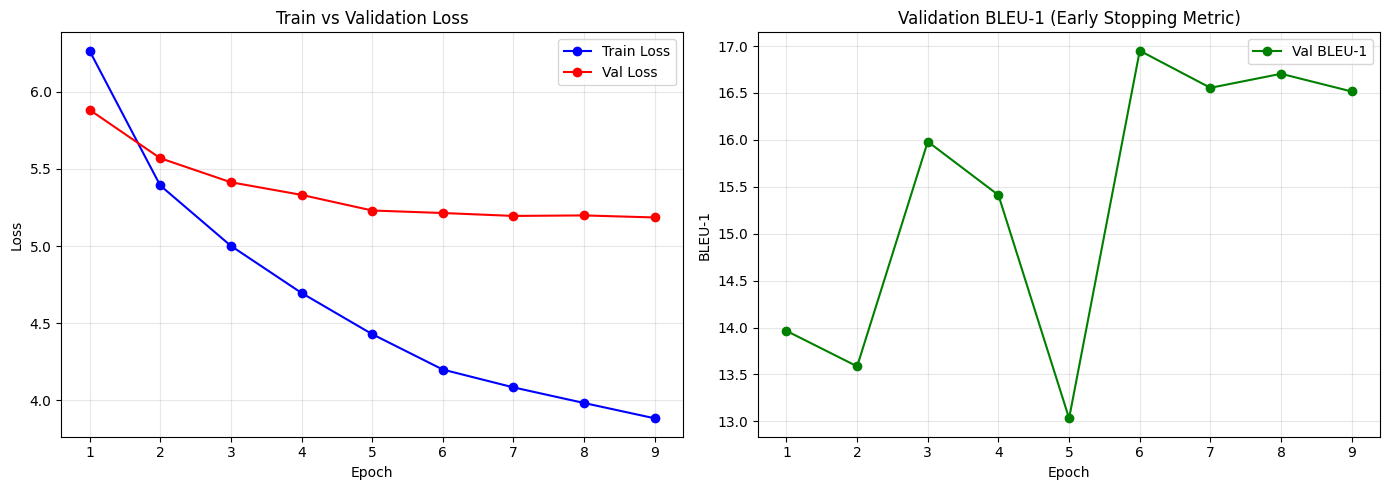

Best epoch by validation BLEU-1: 6
Train loss at best epoch: 4.1987
Val loss at best epoch:   5.2140
Best validation BLEU-1:   16.95
Interpretation: validation BLEU-1 peaks before the final epoch run while train loss keeps falling, so overfitting begins after the best checkpoint. Early stopping preserves the best epoch.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_range, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, val_bleus, 'g-o', label='Val BLEU-1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('BLEU-1')
ax2.set_title('Validation BLEU-1 (Early Stopping Metric)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(val_bleus)) + 1
print(f'Best epoch by validation BLEU-1: {best_epoch}')
print(f'Train loss at best epoch: {train_losses[best_epoch - 1]:.4f}')
print(f'Val loss at best epoch:   {val_losses[best_epoch - 1]:.4f}')
print(f'Best validation BLEU-1:   {val_bleus[best_epoch - 1]:.2f}')



## 8. Load Best Model & Generate Test Predictions

Load the instructor-provided held-out test set and generate predictions. The PDF expects 1,000 Java code-summary pairs, so the notebook prints a warning if the provided file has a different size and continues with the available file for exploratory evaluation.


In [14]:
# Load best checkpoint
import ast

EXPECTED_TEST_SAMPLES = 1000

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print('Best model loaded.')

# Load test data from the provided CSV
test_codes, test_code_ids, test_code_lengths, test_refs = [], [], [], []
with open('provided-files/dataset/test_dataset_tokenized.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_codes.append(row['code'])
        ids = ast.literal_eval(row['code_ids'])
        test_code_ids.append(ids)
        test_code_lengths.append(len(ids))
        test_refs.append(row['summary'])

if not test_codes:
    raise ValueError('No test samples were loaded from provided-files/dataset/test_dataset_tokenized.csv.')

if len(test_codes) != EXPECTED_TEST_SAMPLES:
    print(
        f'WARNING: assignment PDF expects exactly {EXPECTED_TEST_SAMPLES} held-out test samples, but '
        f'provided-files/dataset/test_dataset_tokenized.csv contains {len(test_codes)}. '
        'Continuing with the available file, but the resulting test metrics are not final PDF-compliant results.'
    )

print(f'Test samples: {len(test_codes)}')
print(f'Sample code: {test_codes[0][:150]}...')
print(f'Sample ref:  {test_refs[0]}')


Best model loaded.
Test samples: 99
Sample code: public static String[] concatenateStringArrays(String[] array1,String[] array2){ if (Objects.isEmpty(array1)) { return array2; } if (Objects.isEmpty(a...
Sample ref:  concatenate two string arrays into one.


In [15]:
test_preds = []
for ids, length in zip(test_code_ids, test_code_lengths):
    src = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    src_lengths = torch.tensor([length], dtype=torch.long)
    pred_ids = model.generate(src, src_lengths, eos_id=eos_id)
    test_preds.append(decode_ids(pred_ids))

print(f'Generated {len(test_preds)} predictions')

for i in range(5):
    print(f'\n--- Sample {i} ---')
    print(f'Reference:  {test_refs[i]}')
    print(f'Predicted:  {test_preds[i]}')


Generated 99 predictions

--- Sample 0 ---
Reference:  concatenate two string arrays into one.
Predicted:  returns a string representation of the given array.

--- Sample 1 ---
Reference:  return true if the contents of the internal array bytes and the provided array data match.
Predicted:  returns true if the given array is a byte array.

--- Sample 2 ---
Reference:  return true if starting at the given index, the given string matches the given substring.
Predicted:  returns the string of the given string.

--- Sample 3 ---
Reference:  convert an array of primitive booleans to objects.
Predicted:  returns the value of the given array of the given array.

--- Sample 4 ---
Reference:  read a constant_utf8 constant pool entry in the classfilebuffer.
Predicted:  appends a string to the given string.


## 9. Evaluation Metrics

Compute on the held-out test set:
- **BLEU-1, 2, 3, 4** (sacrebleu)
- **METEOR** (nltk)
- **BERTScore** (bert-score)
- **SIDE** (original implementation)

In [ ]:
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from bert_score import score as bert_score_fn

# BLEU
refs_for_bleu = [test_refs]  # sacrebleu expects list of ref lists
for n in [1, 2, 3, 4]:
    bleu = corpus_bleu_score(test_preds, test_refs, n)
    print(f'BLEU-{n}: {bleu:.2f}')

# METEOR
meteor_scores = []
for pred, ref in zip(test_preds, test_refs):
    m = nltk_meteor([ref.split()], pred.split())
    meteor_scores.append(m)
avg_meteor = np.mean(meteor_scores)
print(f'METEOR: {avg_meteor:.4f}')

# BERTSCORE
P, R, F1 = bert_score_fn(test_preds, test_refs, lang='en', verbose=True)
print(f'BERTScore (F1): {F1.mean().item():.4f}')

BLEU-1: 21.59
BLEU-2: 10.96
BLEU-3: 5.68
BLEU-4: 2.94


METEOR: 0.1602


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/3 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 0.58 seconds, 170.97 sentences/sec
BERTScore (F1): 0.8709


In [ ]:
# SIDE
# Uses the original implementation from https://github.com/antonio-mastropaolo/code-summarization-metric
from pathlib import Path
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer as SideTokenizer

!pip install -q gdown

side_repo_dir = Path('code-summarization-metric')
if not side_repo_dir.is_dir():
    !git clone https://github.com/antonio-mastropaolo/code-summarization-metric.git {side_repo_dir}

side_model_root = side_repo_dir / 'finetuned_model'
if not side_model_root.is_dir() or not any(side_model_root.iterdir()):
    import gdown
    side_model_root.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(
        'https://drive.google.com/drive/folders/150xbvYtyuUNsd8hefjiZXqa_eFY8f67K',
        output=str(side_model_root), quiet=False,
    )

def find_side_checkpoint(root):
    for path in [root / 'hard-negatives' / '141205', root / 'baseline' / '103080']:
        if (path / 'config.json').is_file():
            return path
    candidates = sorted(p for p in root.glob('*/*') if (p / 'config.json').is_file())
    if not candidates:
        raise FileNotFoundError(f'No SIDE checkpoint found under {root}')
    return candidates[0]

side_checkpoint = find_side_checkpoint(side_model_root)
print(f'Loading SIDE checkpoint from: {side_checkpoint}')

side_tokenizer = SideTokenizer.from_pretrained(side_checkpoint)
side_model = AutoModel.from_pretrained(side_checkpoint).to(DEVICE)
side_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)

def side_encode(texts, batch_size=32):
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        encoded = side_tokenizer(texts[start:start+batch_size], padding=True, truncation=True, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = side_model(**encoded)
        emb = F.normalize(mean_pooling(out, encoded['attention_mask']), p=2, dim=1)
        all_embeddings.append(emb.cpu())
    return torch.cat(all_embeddings, dim=0)

code_embs = side_encode(test_codes)
pred_embs = side_encode(test_preds)
side_score = F.cosine_similarity(code_embs, pred_embs).mean().item()
print(f'SIDE: {side_score:.4f}')

Loading SIDE checkpoint from: code-summarization-metric/finetuned_model/hard-negatives/141205


SIDE: 0.7536


## 10. Results Summary

In [18]:
print('=' * 40)
print('FINAL TEST RESULTS')
print('=' * 40)
for n in [1, 2, 3, 4]:
    bleu = corpus_bleu_score(test_preds, test_refs, n)
    print(f'BLEU-{n}:      {bleu:.2f}')
print(f'METEOR:      {avg_meteor:.4f}')
print(f'BERTScore:   {F1.mean().item():.4f}')
print(f'SIDE:        {side_score:.4f}')
print('=' * 40)

FINAL TEST RESULTS
BLEU-1:      21.59
BLEU-2:      10.96
BLEU-3:      5.68
BLEU-4:      2.94
METEOR:      0.1602
BERTScore:   0.8709
SIDE:        0.7536
